The definition of the variables used in the Bookbinder dataset is given below. Use choice variable as dependent variable.

Choice: Whether the customer purchased the The Art History of Florence. 1 corresponds to a purchase and 0 corresponds to a nonpurchase.

Gender: 0 = Female and 1 = Male.

Amount purchased: Total money spent on BBBC books.

Frequency: Total number of purchases in the chosen period (used as a proxy for frequency.)

Last purchase (recency of purchase): Months since last purchase.

First purchase: Months since first purchase.

P_Child: Number of children's books purchased.

P_Youth: Number of youth books purchased.

P_Cook: Number of cookbooks purchased.

P_DIY: Number of do-it-yourself books purchased.

P_Art: Number of art books purchased.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

import statsmodels.api as sm
import matplotlib.pyplot as plt

RANDOM_STATE = 42
DATA_URL = 'https://hogut.weebly.com/uploads/1/8/1/6/18163409/bookbinder2.xls'

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

df = pd.read_excel(DATA_URL)
print(df.shape)
df.head()


(3900, 12)


,Gender,Amount purchased,Frequency,Last purchase,First purchase,P_Child,P_Youth,P_Cook,P_DIY,P_Art,Staus,Choice
0,1,113,8,1,8,0,1,0,0,0,Training,Y
1,1,418,6,11,66,0,2,3,2,3,Training,Y
2,1,336,18,6,32,2,0,1,1,2,Training,Y
3,1,180,16,5,42,2,0,0,1,1,Training,Y
4,0,320,2,3,18,0,0,0,1,2,Training,Y


In [2]:
# Convert Choice to 0/1 and split the provided training/test samples.
df = df.copy()
df['Choice'] = df['Choice'].map({'N': 0, 'Y': 1})

features = [
    'Gender', 'Amount purchased', 'Frequency', 'Last purchase', 'First purchase',
    'P_Child', 'P_Youth', 'P_Cook', 'P_DIY', 'P_Art'
]
target = 'Choice'

training_data = df[df['Staus'] == 'Training'].copy()
test_data = df[df['Staus'] == 'Test'].copy()

X_train = training_data[features]
y_train = training_data[target]
X_test = test_data[features]
y_test = test_data[target]

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Training response rate:', y_train.mean().round(4))
print('Test response rate:', y_test.mean().round(4))


Training rows: 1600
Test rows: 2300
Training response rate: 0.25
Test response rate: 0.0887


In [3]:
# Q1 - Logistic regression coefficient significance and direction

X_train_sm = sm.add_constant(X_train, has_constant='add')
logit_sm = sm.Logit(y_train, X_train_sm).fit(disp=False, maxiter=1000)

coef_table = pd.DataFrame({
    'coefficient': logit_sm.params,
    'p_value': logit_sm.pvalues,
    'odds_ratio': np.exp(logit_sm.params),
})
coef_table['significant_5pct'] = coef_table['p_value'] < 0.05
coef_table['effect_on_P(Choice=Yes)'] = np.where(
    coef_table['coefficient'] > 0, 'increase', 'decrease'
)

print(logit_sm.summary())
print('\nCoefficient significance table:')
display(coef_table)

significant_vars = coef_table.drop(index='const').query('significant_5pct')
print('\nAnswer Q1a: variables with p-value < 0.05 have coefficients significantly different from 0.')
print('Significant variables:', ', '.join(significant_vars.index) if len(significant_vars) else 'None')
print('\nAnswer Q1b: among significant variables:')
for var, row in significant_vars.iterrows():
    direction = 'increase' if row['coefficient'] > 0 else 'decrease'
    print(f'- {var}: coefficient={row["coefficient"]:.4f}, p={row["p_value"]:.4g}; it tends to {direction} the probability of Choice=Yes.')


                           Logit Regression Results                           
Dep. Variable:                 Choice   No. Observations:                 1600
Model:                          Logit   Df Residuals:                     1589
Method:                           MLE   Df Model:                           10
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2264
Time:                        16:24:27   Log-Likelihood:                -696.08
converged:                       True   LL-Null:                       -899.74
Covariance Type:            nonrobust   LLR p-value:                 2.612e-81
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3515      0.214     -1.640      0.101      -0.772       0.069
Gender              -0.8632      0.137     -6.280      0.000      -1.133      -0.594
Amount purchased     0.0019 

,coefficient,p_value,odds_ratio,significant_5pct,effect_on_P(Choice=Yes)
const,-0.3515,0.1011,0.7036,False,decrease
Gender,-0.8632,0.0000,0.4218,True,decrease
Amount purchased,0.0019,0.0186,1.0019,True,increase
Frequency,-0.0755,0.0000,0.9273,True,decrease
Last purchase,0.6118,0.0000,1.8437,True,increase
First purchase,-0.0148,0.2483,0.9853,False,decrease
P_Child,-0.8112,0.0000,0.4443,True,decrease
P_Youth,-0.6370,0.0000,0.5289,True,decrease
P_Cook,-0.9230,0.0000,0.3973,True,decrease
P_DIY,-0.9059,0.0000,0.4042,True,decrease



Answer Q1a: variables with p-value < 0.05 have coefficients significantly different from 0.
Significant variables: Gender, Amount purchased, Frequency, Last purchase, P_Child, P_Youth, P_Cook, P_DIY, P_Art

Answer Q1b: among significant variables:
- Gender: coefficient=-0.8632, p=3.378e-10; it tends to decrease the probability of Choice=Yes.
- Amount purchased: coefficient=0.0019, p=0.01856; it tends to increase the probability of Choice=Yes.
- Frequency: coefficient=-0.0755, p=5.345e-06; it tends to decrease the probability of Choice=Yes.
- Last purchase: coefficient=0.6118, p=6.975e-11; it tends to increase the probability of Choice=Yes.
- P_Child: coefficient=-0.8112, p=3.623e-12; it tends to decrease the probability of Choice=Yes.
- P_Youth: coefficient=-0.6370, p=8.867e-06; it tends to decrease the probability of Choice=Yes.
- P_Cook: coefficient=-0.9230, p=1.118e-14; it tends to decrease the probability of Choice=Yes.
- P_DIY: coefficient=-0.9059, p=2.905e-10; it tends to decrea

In [4]:
# Q2 - KNN with k selected by cross-validation, then test-set performance

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid={'model__n_neighbors': list(range(1, 51, 2))},
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
)
knn_grid.fit(X_train, y_train)

best_k = knn_grid.best_params_['model__n_neighbors']
best_knn = knn_grid.best_estimator_
knn_pred = best_knn.predict(X_test)
knn_proba = best_knn.predict_proba(X_test)[:, 1]

knn_metrics = pd.DataFrame({
    'metric': ['selected_k', 'cv_accuracy', 'test_accuracy', 'test_recall', 'test_precision', 'test_auc'],
    'value': [
        best_k,
        knn_grid.best_score_,
        accuracy_score(y_test, knn_pred),
        recall_score(y_test, knn_pred),
        precision_score(y_test, knn_pred, zero_division=0),
        roc_auc_score(y_test, knn_proba),
    ]
})

print(f'Best k chosen by 5-fold CV accuracy: {best_k}')
display(knn_metrics)
print('Confusion matrix for KNN on test data:')
display(pd.DataFrame(confusion_matrix(y_test, knn_pred),
                     index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))


Best k chosen by 5-fold CV accuracy: 43


,metric,value
0,selected_k,43.0000
1,cv_accuracy,0.7831
2,test_accuracy,0.9061
3,test_recall,0.2010
4,test_precision,0.4362
5,test_auc,0.7838


Confusion matrix for KNN on test data:


,Predicted 0,Predicted 1
Actual 0,2043,53
Actual 1,163,41


In [5]:
# Q3 - Compare Logistic Regression, Naive Bayes, MLP, SVM, LightGBM, and optimized KNN

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
        proba = (scores - scores.min()) / (scores.max() - scores.min())
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'AUC': roc_auc_score(y_test, proba),
        'Confusion Matrix': confusion_matrix(y_test, pred),
    }

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Naive Bayes': GaussianNB(),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
    ]),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    f'KNN (k={best_k})': best_knn,
}

results = [evaluate_model(name, model, X_train, y_train, X_test, y_test) for name, model in models.items()]
metrics_df = pd.DataFrame(results).drop(columns='Confusion Matrix')

print('Test-set performance metrics:')
display(metrics_df.sort_values('AUC', ascending=False).reset_index(drop=True))

print('Confusion matrices:')
for result in results:
    print(f"\n{result['Model']}")
    display(pd.DataFrame(result['Confusion Matrix'],
                         index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

best_by_metric = {
    metric: metrics_df.loc[metrics_df[metric].idxmax(), 'Model']
    for metric in ['Accuracy', 'Recall', 'Precision', 'AUC']
}
print('\nBest model by metric:')
for metric, model_name in best_by_metric.items():
    value = metrics_df.loc[metrics_df['Model'] == model_name, metric].iloc[0]
    print(f'- {metric}: {model_name} ({value:.4f})')


Test-set performance metrics:


,Model,Accuracy,Recall,Precision,AUC
0,Logistic Regression,0.8896,0.3775,0.3775,0.8007
1,KNN (k=43),0.9061,0.2010,0.4362,0.7838
2,SVM,0.9026,0.2500,0.4180,0.7792
3,LightGBM,0.8574,0.3480,0.2669,0.7599
4,Naive Bayes,0.8483,0.3088,0.2325,0.7444
5,MLP,0.8483,0.3627,0.2526,0.7360


Confusion matrices:

Logistic Regression


,Predicted 0,Predicted 1
Actual 0,1969,127
Actual 1,127,77



Naive Bayes


...


LightGBM


,Predicted 0,Predicted 1
Actual 0,1901,195
Actual 1,133,71



KNN (k=43)


,Predicted 0,Predicted 1
Actual 0,2043,53
Actual 1,163,41



Best model by metric:
- Accuracy: KNN (k=43) (0.9061)
- Recall: Logistic Regression (0.3775)
- Precision: KNN (k=43) (0.4362)
- AUC: Logistic Regression (0.8007)


Logistic model AUC on test data: 0.8007
Best probability threshold for targeting: 0.1762
Number of customers to target: 964
True positives at this threshold: 168
False positives at this threshold: 796
Expected profit: $1,053.40

Top rows of the customers recommended for mailing:


,Gender,Amount purchased,Frequency,Last purchase,First purchase,P_Child,P_Youth,P_Cook,P_DIY,P_Art,Staus,Choice,predicted_probability,target_mail
2990,1,221,10,7,36,0,0,0,1,3,Test,0,0.9608,True
1763,1,250,20,12,88,1,0,2,1,4,Test,1,0.9461,True
1714,0,201,4,7,22,1,1,0,1,2,Test,1,0.9299,True
1682,0,225,2,2,8,0,0,0,0,2,Test,1,0.9145,True
1702,0,309,6,4,18,0,0,0,1,2,Test,1,0.9136,True



Saved targeted customer list to bookbinder_targeted_customers.csv


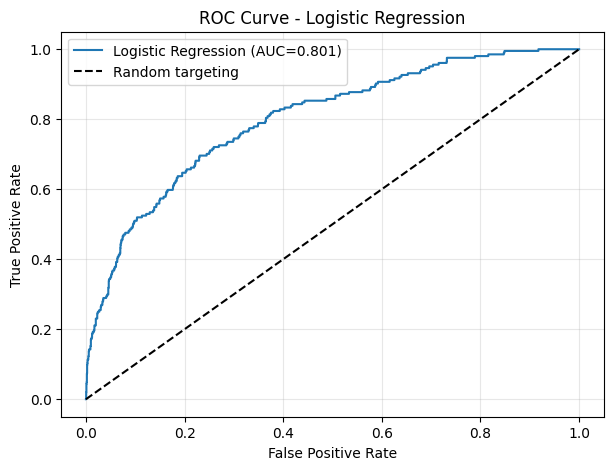


Answer Q4: Bookbinders should target test-data customers with predicted purchase probability >= 0.1762. This gives the highest expected profit among all tested thresholds.


In [6]:
# Q4 - Profit-based targeting using the logistic regression model

profit_per_true_positive = 10.00 - 0.65
cost_per_false_positive = 0.65

logistic_for_profit = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
logistic_for_profit.fit(X_train, y_train)
test_prob = logistic_for_profit.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob)
logistic_auc = roc_auc_score(y_test, test_prob)

threshold_rows = []
for threshold in np.sort(np.unique(test_prob)):
    target_pred = (test_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, target_pred).ravel()
    profit = tp * profit_per_true_positive - fp * cost_per_false_positive
    threshold_rows.append({
        'threshold': threshold,
        'targeted_customers': int(tp + fp),
        'true_positives': int(tp),
        'false_positives': int(fp),
        'profit': profit,
    })

profit_table = pd.DataFrame(threshold_rows)
best_profit_row = profit_table.loc[profit_table['profit'].idxmax()]
best_threshold = best_profit_row['threshold']

test_targeting = test_data.copy()
test_targeting['predicted_probability'] = test_prob
test_targeting['target_mail'] = test_targeting['predicted_probability'] >= best_threshold

targeted_customers = test_targeting[test_targeting['target_mail']].copy()
targeted_customers.to_csv('bookbinder_targeted_customers.csv', index=False)

print(f'Logistic model AUC on test data: {logistic_auc:.4f}')
print(f'Best probability threshold for targeting: {best_threshold:.4f}')
print(f'Number of customers to target: {int(best_profit_row["targeted_customers"])}')
print(f'True positives at this threshold: {int(best_profit_row["true_positives"])}')
print(f'False positives at this threshold: {int(best_profit_row["false_positives"])}')
print(f'Expected profit: ${best_profit_row["profit"]:,.2f}')
print('\nTop rows of the customers recommended for mailing:')
display(targeted_customers.sort_values('predicted_probability', ascending=False).head())
print('\nSaved targeted customer list to bookbinder_targeted_customers.csv')

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={logistic_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random targeting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('\nAnswer Q4: Bookbinders should target test-data customers with predicted purchase probability '
      f'>= {best_threshold:.4f}. This gives the highest expected profit among all tested thresholds.')
